In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/default-of-credit-card-clients-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'default-of-credit-card-clients-dataset' dataset.
Path to dataset files: /kaggle/input/default-of-credit-card-clients-dataset


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [ ]:
data=pd.read_csv(f"{path}/UCI_Credit_Card.csv")
data.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [ ]:
data.shape

(30000, 25)

In [ ]:
data.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default.payment.next.month'],
      dtype='object')

In [ ]:
duplicate_count=data.duplicated().sum()
null_count=data.isnull().sum().sum()
print(f"duplicate count:{duplicate_count}")
print(f"null count:{null_count}")

duplicate count:0
null count:0


Target distribution:
default.payment.next.month
0    0.7788
1    0.2212
Name: proportion, dtype: float64


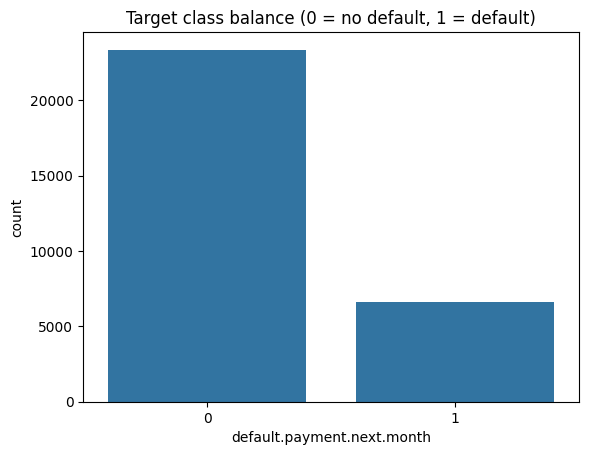

In [ ]:
print("Target distribution:")
print(data['default.payment.next.month'].value_counts(normalize=True).rename("proportion"))

sns.countplot(x="default.payment.next.month", data=data)
plt.title("Target class balance (0 = no default, 1 = default)")
plt.show()

In [ ]:
for col in data.columns:
  print(f"{col}:{sorted(data[col].unique().tolist())}\nunique count: {len(data[col].unique())}  min:{data[col].unique().min()}  max:{data[col].unique().max()}\n")

ID:[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221,

datacleaning

In [ ]:
data=data.drop(["ID"],axis=1)

EDUCATION: (1=graduate school, 2=university, 3=high school, 4=others,5=unknown)

MARRIAGE: Marital status (1=married, 2=single, 3=others)

 Repayment status(

0=pay duly,

1=payment delay for one month,

2=payment delay for two months,

… 8=payment delay for eight months or more)

Bill_amnt all positive

In [ ]:
def encoding_correction(data):
  data.loc[
    (data["EDUCATION"] == 0) |
    (data["EDUCATION"] == 6),
    "EDUCATION"] =5
  data.loc[
    (data["MARRIAGE"] == 0),
    "MARRIAGE"] =3
  for i in ['PAY_0','PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']:
    data.loc[(data[i]==-1)|(data[i]==-2),i]=0
  for i in ['BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']:
       data[i]=data[i].abs()

  return data

In [ ]:
X = data.drop("default.payment.next.month", axis=1)
y = data["default.payment.next.month"]

X=encoding_correction(X)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
X=X_train
X['default']=y_train

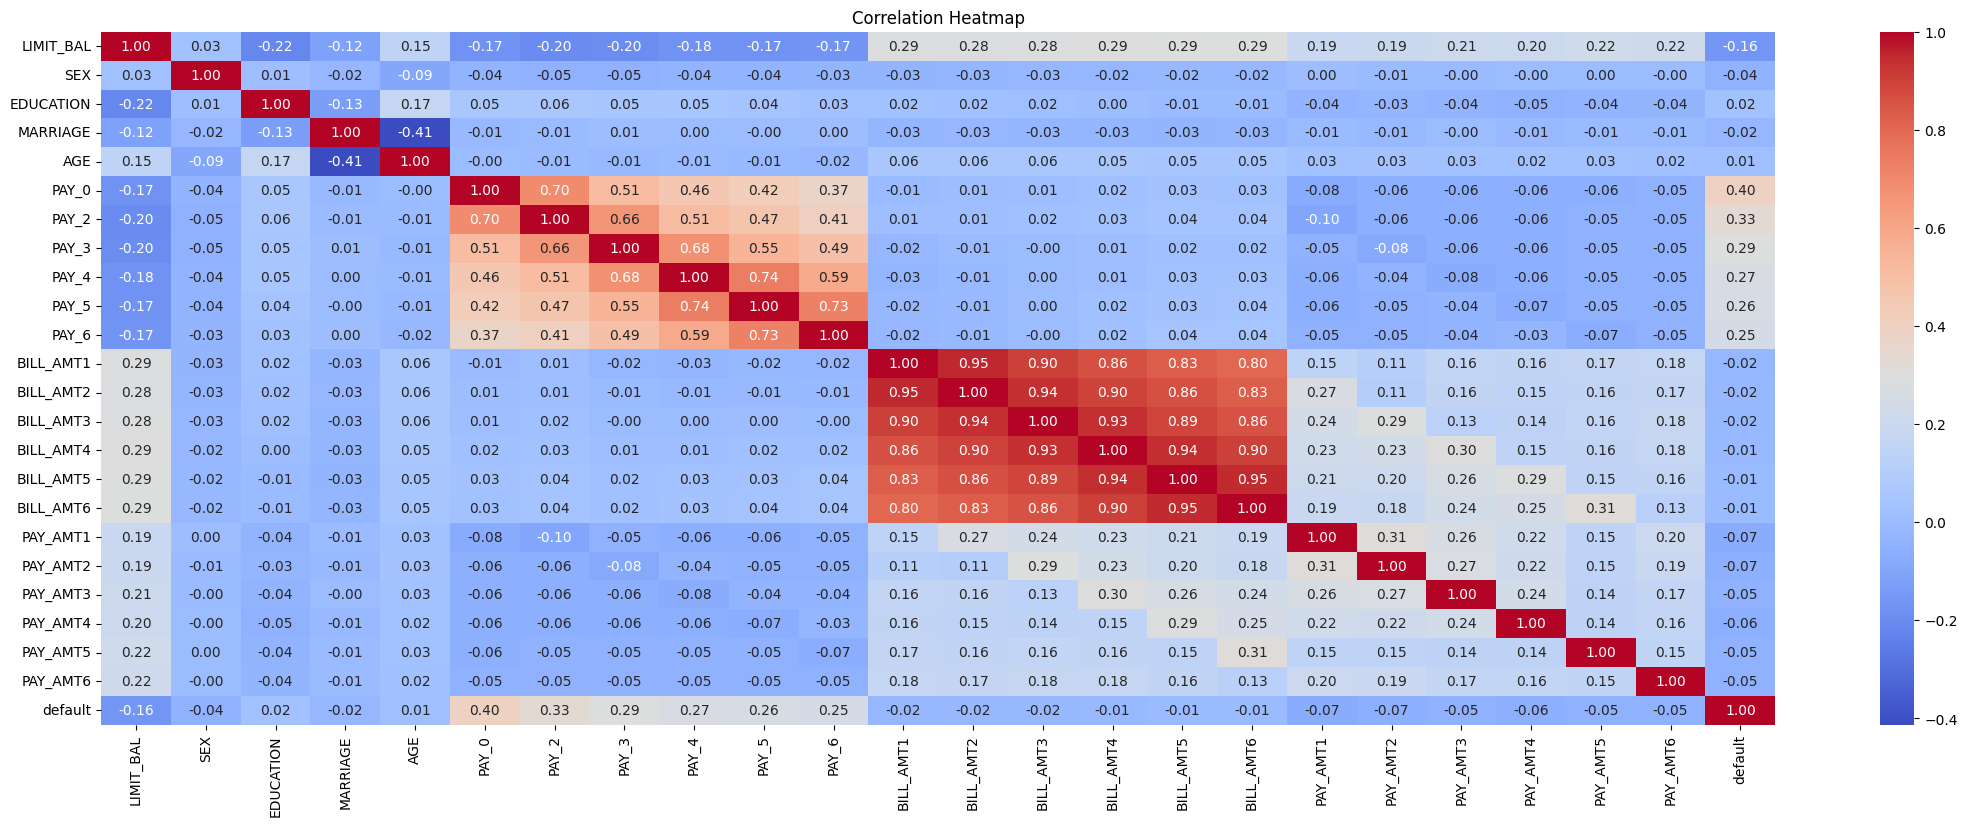

In [ ]:

plt.figure(figsize=(27, 9))

sns.heatmap(
    X.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

pay_0 ,pay_1,... pay_6 are highly corelated with each other transitively so extracting pay_0

Bill_AMt1 ...Bill_Amt6 very highly corelated extracting Bill_AMt1


In [ ]:
def newfeatures(data):
  data['Total_bill']=data['BILL_AMT1']+data['BILL_AMT2']+data['BILL_AMT3']+data['BILL_AMT4']+data['BILL_AMT5']+data['BILL_AMT6']
  data['Total_pay']=data['PAY_AMT1']+data['PAY_AMT2']+data['PAY_AMT3']+data['PAY_AMT4']+data['PAY_AMT5']+data['PAY_AMT6']
  data['Outstanding'] = data['Total_bill'] - data['Total_pay']
  return data

In [ ]:
def features(X):
  X=newfeatures(X)
  X=X.drop(['PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6','BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6'], axis=1)

  return X

In [ ]:
X_train=X.drop(['default'], axis=1)
y_train =X['default']

# dropinfg Features
X_train=features(X_train)

#  Random Forest
model = RandomForestClassifier(
    n_estimators=20,
    random_state=42,
    n_jobs=-1
)

# Train
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=20, n_jobs=-1, random_state=42)

In [ ]:
importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance)

PAY_0          0.145541
Total_pay      0.078616
BILL_AMT1      0.076857
Outstanding    0.076774
AGE            0.075675
Total_bill     0.074713
LIMIT_BAL      0.069215
PAY_AMT1       0.065727
PAY_AMT2       0.064199
PAY_AMT3       0.058787
PAY_AMT4       0.055735
PAY_AMT5       0.054641
PAY_AMT6       0.053773
EDUCATION      0.022044
MARRIAGE       0.014633
SEX            0.013069
dtype: float64


In [ ]:
def final_feature(X):
  for i in importance.keys():
    if importance[i]<0.069:
      X=X.drop([i],axis=1)
  return X


In [ ]:
X_train=final_feature(X_train)

In [ ]:
X_train.columns

Index(['LIMIT_BAL', 'AGE', 'PAY_0', 'BILL_AMT1', 'Total_bill', 'Total_pay',
       'Outstanding'],
      dtype='object')

In [ ]:
X_train.describe()

,LIMIT_BAL,AGE,PAY_0,BILL_AMT1,Total_bill,Total_pay,Outstanding
count,24000.000000,24000.000000,24000.000000,24000.000000,2.400000e+04,2.400000e+04,2.400000e+04
mean,167364.666667,35.432625,0.357667,51149.911083,2.694018e+05,3.150949e+04,2.378923e+05
std,129511.313151,9.195256,0.760766,73475.659435,3.780214e+05,5.910344e+04,3.621098e+05
min,10000.000000,21.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,-2.671514e+06
25%,50000.000000,28.000000,0.000000,3559.750000,2.942775e+04,6.700000e+03,4.997750e+03
50%,140000.000000,34.000000,0.000000,22334.500000,1.265190e+05,1.443400e+04,1.018575e+05
75%,240000.000000,41.000000,0.000000,66978.250000,3.417865e+05,3.385625e+04,3.038275e+05
max,1000000.000000,75.000000,8.000000,964511.000000,5.263883e+06,3.764066e+06,4.116080e+06


In [ ]:
# Prediction on original untouched test data
X_test=features(X_test)
X_test=final_feature(X_test)

Synthetic data genartion for balance training

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

Random Forest model train

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

# SMOTE + Random Forest Pipeline
rf_model = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("rf", RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

# Hyperparameter search space for Random Forest
# rf_param_dist = {
#     "rf__n_estimators": [100, 200, 250, 300 ],
#     "rf__max_depth": [None, 10, 15, 20, 25, 30],
#     "rf__min_samples_split": [2, 5, 10],
#     "rf__min_samples_leaf": [1, 2, 4],
#     "rf__max_features": ["sqrt", "log2", 0.5, 0.8],
#     "rf__class_weight": [None, "balanced", "balanced_subsample"]
# }

# Lighter Hyperparameter search space for Random Forest
rf_param_dist = {
    "rf__n_estimators": [100, 200, 300],
    "rf__max_depth": [None, 10, 20],
    "rf__min_samples_split": [2, 5],
    "rf__min_samples_leaf": [1, 2],
    "rf__max_features": ["sqrt", "log2", 0.5],
    "rf__class_weight": [None, "balanced"]
}

# Stratified Cross Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Randomized Cross-Validation / Hyperparameter Search
rf_random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=rf_param_dist,
    n_iter=10, #============================================
    scoring={
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1"
    },
    refit="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Run randomized search
rf_random_search.fit(X_train, y_train)

# Use the best Random Forest configuration for all downstream testing
rf_model = rf_random_search.best_estimator_

# CV metrics for the best configuration selected by F1
best_index = rf_random_search.best_index_
cv_rf = {
    "Accuracy": float(rf_random_search.cv_results_["mean_test_accuracy"][best_index]),
    "Precision": float(rf_random_search.cv_results_["mean_test_precision"][best_index]),
    "Recall": float(rf_random_search.cv_results_["mean_test_recall"][best_index]),
    "F1 Score": float(rf_random_search.cv_results_["mean_test_f1"][best_index])
}

print("Best Random Forest Parameters:")
print(rf_random_search.best_params_)
print("\nBest CV F1 Score:", rf_random_search.best_score_)
print("\nFinal Random Forest CV Metrics:")
print(cv_rf)


Fitting 5 folds for each of 10 candidates, totalling 50 fits


/usr/local/lib/python3.13/dist-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Random Forest Parameters:
{'rf__n_estimators': 100, 'rf__min_samples_split': 5, 'rf__min_samples_leaf': 2, 'rf__max_features': 0.5, 'rf__max_depth': 10, 'rf__class_weight': 'balanced'}

Best CV F1 Score: 0.5119699954223077

Final Random Forest CV Metrics:
{'Accuracy': 0.7510833333333334, 'Precision': 0.4520906906201202, 'Recall': 0.5903175592084361, 'F1 Score': 0.5119699954223077}


XGBoost model train

In [ ]:
from xgboost import XGBClassifier

# SMOTE + XGBoost Pipeline
xgb_model = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("xgb", XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        eval_metric="logloss"
    ))
])

# Stratified Cross Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Cross Validation
cv_results = cross_validate(
    xgb_model,
    X_train,
    y_train,
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1"],
    n_jobs=-1
)

cv_xgb = {
    "Accuracy": float(cv_results["test_accuracy"].mean()),
    "Precision": float(cv_results["test_precision"].mean()),
    "Recall": float(cv_results["test_recall"].mean()),
    "F1 Score": float(cv_results["test_f1"].mean())
}

# Final training
xgb_model.fit(X_train, y_train)

Pipeline(steps=[('smote', SMOTE(random_state=42)),
                ('xgb',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=True, eval_metric='logloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

Logistic Regression model Train

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# SMOTE + Scaling + Logistic Regression
lr_model = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

# Stratified Cross Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Cross Validation
cv_results = cross_validate(
    lr_model,
    X_train,
    y_train,
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1"],
    n_jobs=-1
)

cv_lr = {
    "Accuracy": float(cv_results["test_accuracy"].mean()),
    "Precision": float(cv_results["test_precision"].mean()),
    "Recall": float(cv_results["test_recall"].mean()),
    "F1 Score": float(cv_results["test_f1"].mean())
}

# Final training
lr_model.fit(X_train, y_train)

Pipeline(steps=[('smote', SMOTE(random_state=42)), ('scaler', StandardScaler()),
                ('lr', LogisticRegression(max_iter=1000, random_state=42))])

Training matrices

In [ ]:
print("Training Random Forest:")
print(cv_rf)
print("\nTraining XGBoost:")
print(cv_xgb)
print("\nTraining Logistic Regression:")
print(cv_lr)



Training Random Forest:
{'Accuracy': 0.7510833333333334, 'Precision': 0.4520906906201202, 'Recall': 0.5903175592084361, 'F1 Score': 0.5119699954223077}

Training XGBoost:
{'Accuracy': 0.74675, 'Precision': 0.44545980597681956, 'Recall': 0.5903184466915516, 'F1 Score': 0.507699515004511}

Training Logistic Regression:
{'Accuracy': 0.7734166666666666, 'Precision': 0.4893058142411242, 'Recall': 0.5385203171509663, 'F1 Score': 0.5125031741870092}


In [ ]:
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:


def metrices(y_test,y_pred,th,ty):
    # Metrics
  precision = precision_score(y_test, y_pred)
  recall = recall_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)
  acc=accuracy_score(y_test, y_pred)

  # Confusion Matrix
  cm = confusion_matrix(y_test, y_pred)

  sns.heatmap(
      cm,
      annot=True,
      fmt="d",
      cmap="plasma",
      xticklabels=["Non-Default", "Default"],
      yticklabels=["Non-Default", "Default"]
  )

  plt.xlabel("Predicted")
  plt.ylabel("Actual")
  plt.title(f"{ty}\nAccuracy:{acc}\nPrecision:{precision}\nRecall:{recall}\nF1 Score:{f1}\nConfusion Matrix (Threshold ={th})")


Final prediction model

In [ ]:
X_test.shape

(6000, 7)

In [ ]:
rf_th=.44
xgb_th=.46
lr_th=0.48

RandomForest Testing

In [ ]:
# Test prediction probability
rf_prob = rf_model.predict_proba(X_test)[:, 1]
rf_pred= (rf_prob >=rf_th).astype(int)



XGBoost Testing

In [ ]:
# Test prediction probability
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]
xgb_pred= (xgb_prob >=xgb_th).astype(int)



Logistic Regression Testing

In [ ]:
# Test prediction probability
lr_prob = lr_model.predict_proba(X_test)[:, 1]
lr_pred= (lr_prob >= lr_th).astype(int)



Metrices plotting

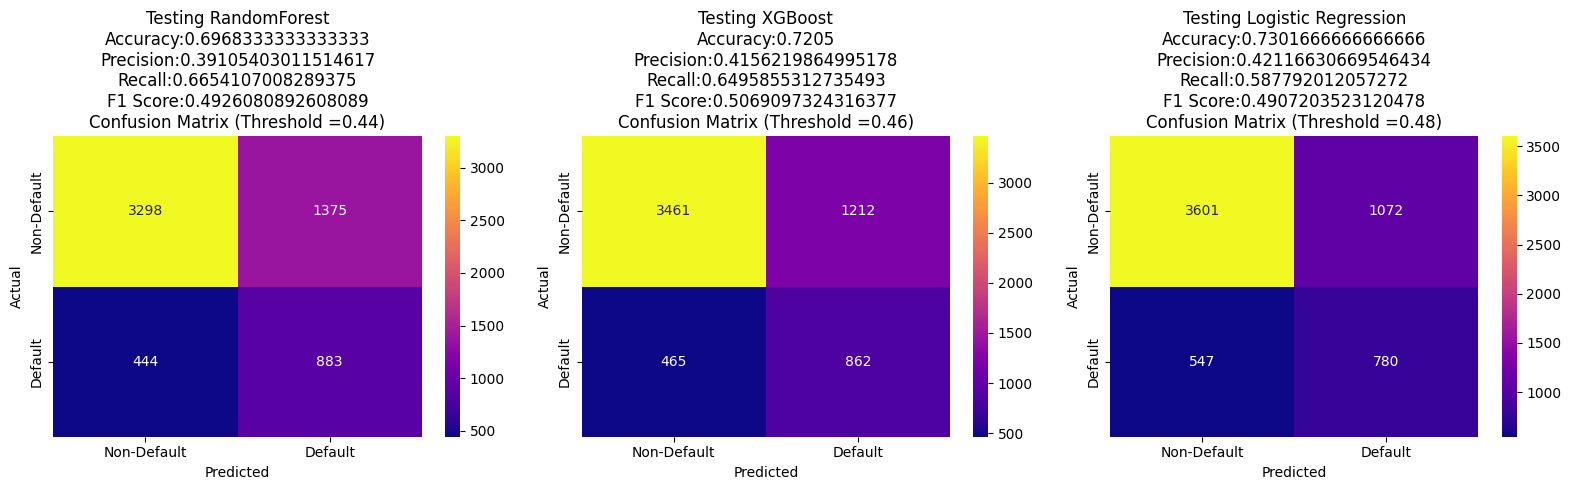

In [ ]:
plt.figure(figsize=(16,5))
plt.subplot(1,3,1)
metrices(y_test,rf_pred,rf_th,"Testing RandomForest")
plt.subplot(1,3,2)
metrices(y_test,xgb_pred,xgb_th,"Testing XGBoost")
plt.subplot(1,3,3)
metrices(y_test,lr_pred,lr_th,"Testing Logistic Regression")

plt.tight_layout()
plt.show()

ROC AUC Curve

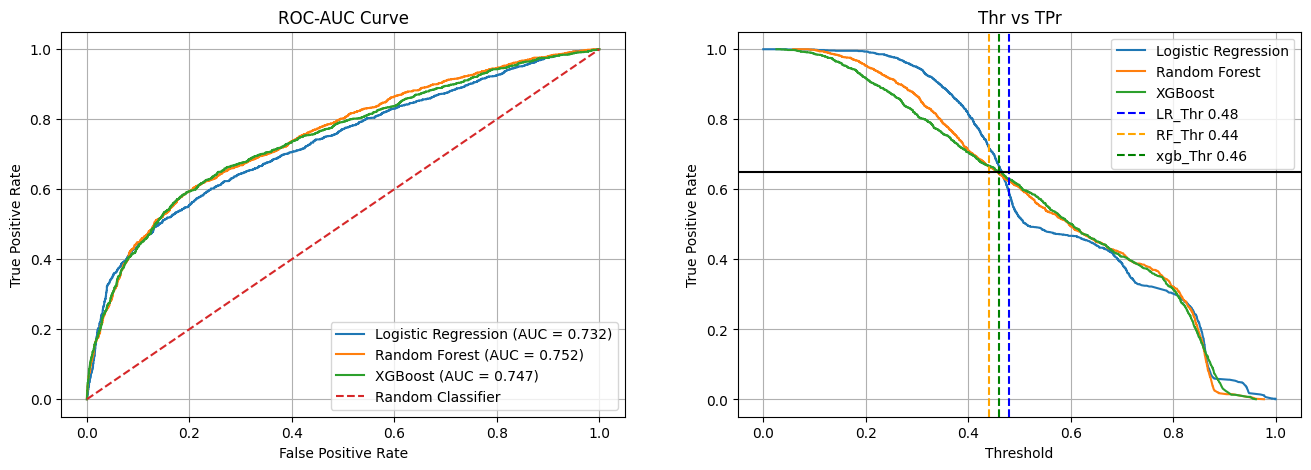

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# ROC Curve

lr_fpr, lr_tpr,lr_thr = roc_curve(y_test, lr_prob)
rf_fpr, rf_tpr,rf_thr= roc_curve(y_test, rf_prob)
xgb_fpr, xgb_tpr,xgb_thr= roc_curve(y_test, xgb_prob)


# AUC

lr_auc = roc_auc_score(y_test, lr_prob)
rf_auc = roc_auc_score(y_test, rf_prob)
xgb_auc = roc_auc_score(y_test, xgb_prob)


# Plot

plt.figure(figsize=(16,5))
plt.subplot(1,2,1)

plt.plot(lr_fpr, lr_tpr,label=f"Logistic Regression (AUC = {lr_auc:.3f})")

plt.plot(rf_fpr, rf_tpr,label=f"Random Forest (AUC = {rf_auc:.3f})")

plt.plot(xgb_fpr, xgb_tpr,label=f"XGBoost (AUC = {xgb_auc:.3f})")

# Random classifier
plt.plot([0, 1],[0, 1],linestyle="--",label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve")

plt.legend()
plt.grid()

plt.subplot(1,2,2)

plt.plot(lr_thr, lr_tpr,label="Logistic Regression")

plt.plot(rf_thr, rf_tpr,label="Random Forest")

plt.plot(xgb_thr, xgb_tpr,label="XGBoost")

plt.xlabel("Threshold")
plt.ylabel("True Positive Rate")
plt.title("Thr vs TPr")


plt.axvline(x=lr_th, linestyle="--", label=f"LR_Thr {lr_th}", color="blue")
plt.axvline(x=rf_th, linestyle="--", label=f"RF_Thr {rf_th}", color="orange")
plt.axvline(x=xgb_th, linestyle="--", label=f"xgb_Thr {xgb_th}",color="green")
plt.axhline(y=0.65,color="black")

plt.legend()
plt.grid()

plt.show()

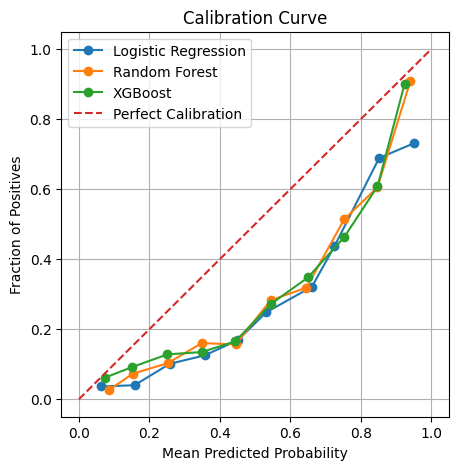

In [ ]:
from sklearn.calibration import calibration_curve


# Calibration curve
lr_true, lr_pred = calibration_curve(y_test, lr_prob, n_bins=10)
rf_true, rf_pred = calibration_curve(y_test, rf_prob, n_bins=10)
xgb_true, xgb_pred = calibration_curve(y_test, xgb_prob, n_bins=10)

# Plot
plt.figure(figsize=(5, 5))

plt.plot(lr_pred, lr_true, marker='o', label='Logistic Regression')
plt.plot(rf_pred, rf_true, marker='o', label='Random Forest')
plt.plot(xgb_pred, xgb_true, marker='o', label='XGBoost')

# Perfect calibration line
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfect Calibration')

plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve')
plt.legend()
plt.grid()
plt.show()

In [ ]:
from statistics import mode

data={'LIMIT_BAL':70000, 'AGE':30, 'PAY_0':1, 'BILL_AMT1':20000, 'Total_bill':30000, 'Total_pay':14000,
       'Outstanding':16000}
# data=X_test.iloc[5155].to_dict()
dt=pd.DataFrame(data,index=[0])
# dt=pd.DataFrame(data,index=[0])
pred_rf = round(rf_model.predict_proba(dt)[0][1],3)
pred_xgb = xgb_model.predict_proba(dt)[0][1]
pred_lr = lr_model.predict_proba(dt)[0][1]
rfp=(pred_rf>=rf_th).astype(int)
xgbp=(pred_xgb>=xgb_th).astype(int)
lrp=(pred_lr>=lr_th).astype(int)
print(f"Random Forest  \t    Prediction:{round(float(pred_rf),2)}\tdefault:{rfp}")
print(f"XGBoost        \t    Prediction: {round(float(pred_xgb),2)}\tdefault:{xgbp}")
print(f"Logistic Regression Prediction:{round(float(pred_lr),2)}\tdefault:{lrp}")

m = mode([rfp, xgbp,lrp])
print("\nFINAL VERDICT: ",end=" ")
print("DEFAULT") if m==1 else print("NOT DEFAULT")


Random Forest  	    Prediction:0.49	default:1
XGBoost        	    Prediction: 0.47	default:1
Logistic Regression Prediction:0.66	default:1

FINAL VERDICT:  DEFAULT
